# SOC model steps 1-2: minimal bright/dark and spin-Peierls mode

This notebook keeps the model intentionally small. Step 1 uses the same builder as Step 2, but turns off the spin-Peierls mode and keeps only a coherent bright-dark mixing. Step 2 turns on the effective spin-Peierls mode and integrates the response over k.

In [650]:
from pathlib import Path
import json
import sys

import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "SolverV8").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from SolverV8 import (
    LiouvilleSpectroscopySolver,
    SpectroscopyPlotter,
    standard_nq_protocol,
)


### Parameters

The default numerical values follow the older SOC notebooks: `Delta_dark = 0.90 eV`, `Delta_Bright = 1.50 eV`, `Lambda_SOC = 0.15`, `T = 7 K`, `T_SP_0 = 14 K`, `J = 1`, `delta_0 = 0.01`, and `beta = 0.5`.

For Step 1, the spin-Peierls-specific parameters are set to zero or one trivial k-point. For Step 2, the same model is used with the effective k-dependent spin-Peierls mode turned on.

In [651]:
base_model_params = {
    # Orbital sector: |g>, |D>, |B>
    "Delta_dark": 0.90,
    "Delta_Bright": 1.0,
    "mu_B": 1.0,
    "mu_D": 0.0,

    # Bright-dark mixing controls
    "V0": 0.0,
    "lambda_delta": 0.0,
    "Lambda_SOC": 0.00,

    # Spin-Peierls effective mode
    "N_k": 100,
    "n_bosons": 2,
    "T": 1.0,
    "T_SP_0": 14.0,
    "B": 0.0,
    "J": 1.0,
    "delta_0": 0.01,
    "beta": 0.5,
    "spin_mode_scale": 1.0,

    # k-dependent coupling shape
    "a_dimer": 1.0,
    "alpha_dimerisation": 0.01,
    "parity": "odd",

    # Dissipation, kept explicit so coherent controls are easy
    "gamma_orb": 0.1,
    "gamma_spin": 0.1,
}

step1_params = {
    **base_model_params,
    "label": "step1_minimal_bright_dark",
    "N_k":1,
    "n_bosons": 1,
    "V0": 0.15,
    "lambda_delta": 0.0,
    "Lambda_SOC": 0.0,
    "delta_0": 0.0,
    "spin_mode_scale": 0.0,
    "gamma_orb": 0.0,
    "gamma_spin": 0.0,
}



solver_params = {
    "T": 0.0,
    "Eta": 0.01,
    "backend": "dense",
    "parallel_backend": "threading",
    "n_jobs": -1,
}


### Model Builder

In [652]:
def spin_peierls_delta(T, B, T_SP_0, delta_0, beta):
    alpha_field = 0.004
    T_SP = max(0.0, T_SP_0 * (1.0 - alpha_field * B**2))
    if T_SP > 0.0 and T < T_SP:
        return delta_0 * (1.0 - T / T_SP) ** beta
    return 0.0


def spin_peierls_dispersion(k, T, B, J, T_SP_0, delta_0, beta):
    delta = spin_peierls_delta(T, B, T_SP_0, delta_0, beta)
    gap = 2.0 * J * delta ** (2.0 / 3.0) if delta > 0.0 else 0.0
    velocity = np.pi * J / 2.0
    omega_k = np.sqrt(gap**2 + (velocity * np.sin(k)) ** 2)
    return omega_k, delta, gap


def k_coupling(k, delta, alpha_dimerisation, a_dimer=1.0, parity="odd"):
    phase = k * a_dimer / 2.0
    eta = delta * alpha_dimerisation
    if parity == "odd":
        return np.sin(phase)
    if parity == "even":
        return np.cos(phase)
    return np.sin(phase) + eta * np.cos(phase)


def lowering_operator(n):
    op = np.zeros((n, n), dtype=complex)
    for upper in range(1, n):
        op[upper - 1, upper] = np.sqrt(upper)
    return op


def build_soc_bright_dark_model(params):
    N_k = int(params["N_k"])
    n_bosons = int(params["n_bosons"])
    if N_k == 1:
        k_array = np.array([0.0])
        k_weights = np.ones(1)
    else:
        k_array = np.linspace(-np.pi, np.pi, N_k, endpoint=False)
        k_weights = np.ones(N_k) / N_k

    ket_g, ket_d, ket_b = 0, 1, 2
    H_orb = np.zeros((3, 3), dtype=complex)
    H_orb[ket_d, ket_d] = params["Delta_dark"]
    H_orb[ket_b, ket_b] = params["Delta_Bright"]

    L_bd = np.zeros((3, 3), dtype=complex)
    L_bd[ket_d, ket_b] = 1.0
    L_bd[ket_b, ket_d] = 1.0

    mu_orb = np.zeros((3, 3), dtype=complex)
    mu_orb[ket_g, ket_b] = params["mu_B"]
    mu_orb[ket_b, ket_g] = params["mu_B"]
    mu_orb[ket_g, ket_d] = params["mu_D"]
    mu_orb[ket_d, ket_g] = params["mu_D"]

    a = lowering_operator(n_bosons)
    adag = a.conj().T
    n_op = adag @ a
    x_op = a + adag

    I_orb = np.eye(3, dtype=complex)
    I_spin = np.eye(n_bosons, dtype=complex)
    dim = 3 * n_bosons

    H_stack = np.zeros((N_k, dim, dim), dtype=complex)
    mu_stack = np.zeros_like(H_stack)
    rho0 = np.zeros_like(H_stack)

    for i_k, k in enumerate(k_array):
        omega_k, delta, gap = spin_peierls_dispersion(
            k,
            params["T"],
            params["B"],
            params["J"],
            params["T_SP_0"],
            params["delta_0"],
            params["beta"],
        )
        V_static = params["V0"] + params["lambda_delta"] * delta
        V_k = k_coupling(
            k,
            delta,
            params["alpha_dimerisation"],
            a_dimer=params["a_dimer"],
            parity=params["parity"],
        )

        H_local = np.kron(H_orb, I_spin)
        H_spin = params["spin_mode_scale"] * omega_k * np.kron(I_orb, n_op)
        H_static_mix = V_static * np.kron(L_bd, I_spin)
        H_mode_mix = params["Lambda_SOC"] * V_k * np.kron(L_bd, x_op)

        H_stack[i_k] = H_local + H_spin + H_static_mix + H_mode_mix
        mu_stack[i_k] = np.kron(mu_orb, I_spin)
        rho0[i_k, 0, 0] = 1.0

    c_ops = []
    if params["gamma_spin"]:
        c_ops.append((np.repeat(np.kron(I_orb, a)[None, :, :], N_k, axis=0), params["gamma_spin"]))
    if params["gamma_orb"]:
        C_bg = np.zeros((3, 3), dtype=complex)
        C_bg[ket_g, ket_b] = 1.0
        C_dg = np.zeros((3, 3), dtype=complex)
        C_dg[ket_g, ket_d] = 1.0
        c_ops.append((np.repeat(np.kron(C_bg, I_spin)[None, :, :], N_k, axis=0), params["gamma_orb"]))
        c_ops.append((np.repeat(np.kron(C_dg, I_spin)[None, :, :], N_k, axis=0), params["gamma_orb"]))

    metadata = {
        "k_array": k_array,
        "k_weights": k_weights,
        "delta": spin_peierls_delta(params["T"], params["B"], params["T_SP_0"], params["delta_0"], params["beta"]),
        "dim": dim,
    }
    return H_stack, mu_stack, c_ops, rho0, metadata


### Solver Setup

In [653]:
def make_solver(params):
    H, mu, c_ops, rho0, meta = build_soc_bright_dark_model(params)

    solver = LiouvilleSpectroscopySolver(solver_params)
    solver.feed_model(
        H,
        mu,
        c_ops_raw=c_ops,
        initial_density_matrix=rho0,
        density_matrix_basis="site",
    )
    return solver, meta



solver_params['Eta'] = 0.001

active_params = step1_params
active_params['V0'] = 0.01
active_params['N_k'] = 1

# active_params = step2_params

solver, meta = make_solver(active_params)
print(active_params["label"])
print("Hilbert dimension:", meta["dim"])
print("N_k:", len(meta["k_array"]))
print("delta:", meta["delta"])
print('Hamiltonien dimensions:', solver.H_eigen.shape)


--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
step1_minimal_bright_dark
Hilbert dimension: 3
N_k: 1
delta: 0.0
Hamiltonien dimensions: (1, 3, 3)


### Third-Order 1Q Pathways With NQ Protocol

In [654]:
arrival_times = [0.0, 100.0, 200.0]
pathways = solver.configure_standard_2d_pathways_with_ufss(arrival_times)

protocol = standard_nq_protocol(
    order=1,
    nq_interval=1,
    detection_interval=3,
    n_interactions=3,
    nq_axis="omega1",
    detection_axis="omega3",
)

rephasing_pathways = solver.get_pathways("rephasing")
unrephasing_pathways = solver.get_pathways("unrephasing")

[(p.name, p.component, p.interactions, p.coherence_orders) for p in pathways]


[('R1', 'rephasing', ('Bu', 'Ku', 'Bd'), (-1, 0, 1)),
 ('R2', 'rephasing', ('Bu', 'Bd', 'Ku'), (-1, 0, 1)),
 ('R3', 'rephasing', ('Bu', 'Ku', 'Ku'), (-1, 0, 1)),
 ('R4', 'unrephasing', ('Ku', 'Bu', 'Ku'), (1, 0, 1)),
 ('R5', 'unrephasing', ('Ku', 'Bu', 'Bd'), (1, 0, 1)),
 ('R6', 'unrephasing', ('Ku', 'Kd', 'Ku'), (1, 0, 1))]

### Spectrum Calculation

The `omega1` axis spans positive and negative 1Q frequencies because the NQ helper separates `+1Q` and `-1Q` contributions from the same protocol.

In [655]:
N_w = 300
omega1 = np.linspace(-1.3, -0.7, N_w)
#omega1 = np.linspace(0.7, 1.3, N_w)
omega3 = np.linspace(0.7, 1.3, N_w)
tau2 = 3.0

result = solver.generate_NQ_spectrum(
    1,
    protocol,
    axes={"omega1": omega1, "omega3": omega3},
    delays={"t2": tau2},
    pathways=pathways,
    k_array=meta["k_array"],
    k_weights=meta["k_weights"],
)

print("Components:", tuple(result.components))
print("Pathways:", tuple(result.pathways))


Calculating 6 pathway spectrum/s on a 300x300 grid with protocol 'standard_1q'.
Using dense prefix-tree pathway reuse.
Components: ('rephasing', 'unrephasing', '+1Q', '-1Q', '1Q')
Pathways: ('R1', 'R2', 'R3', 'R4', 'R5', 'R6')


### Plot Pathways And Rephasing/Unrephasing Totals

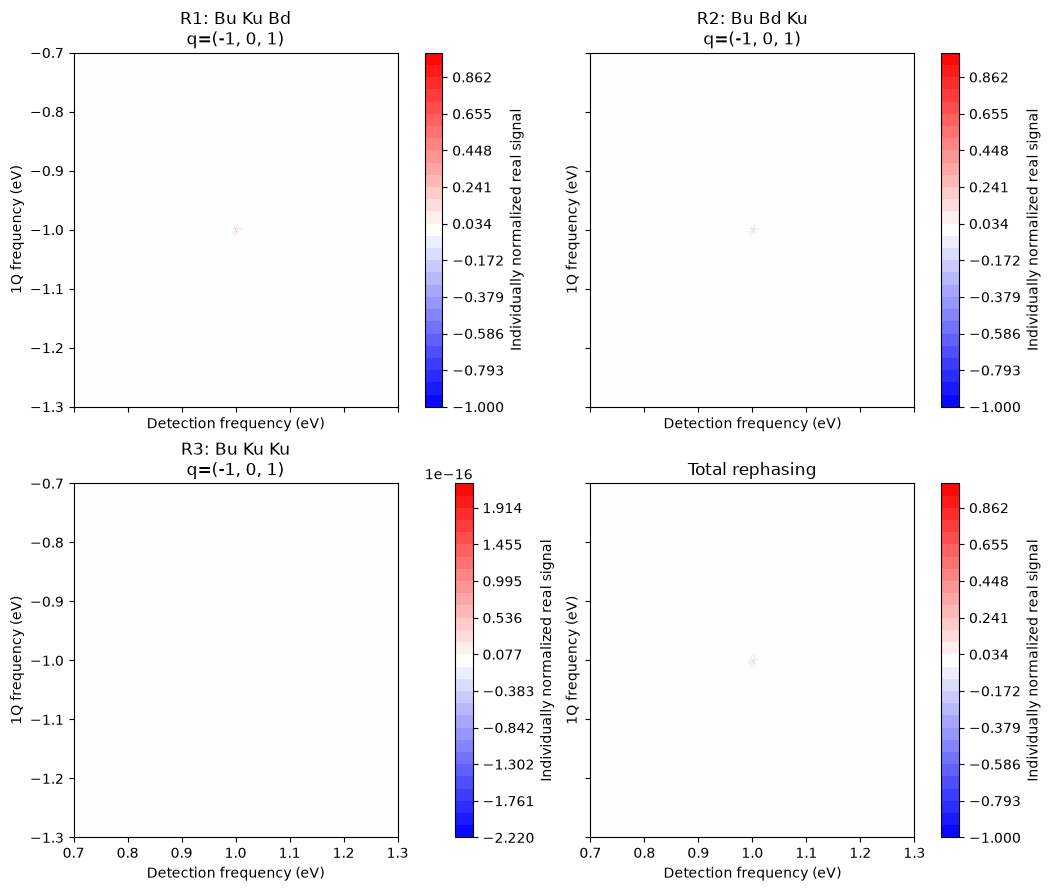

Plotted panels: ('R1', 'R2', 'R3', 'Total rephasing')
Spectrum PDF: c:\Users\falve\OneDrive\Documents\GitHub\LiouvilleSolver\SOC Model\Result_Test\step1_minimal_bright_dark\Eta_scan\SOC_rephasing_real_Eta_0.001_V0_0.01.pdf
Parameter file: c:\Users\falve\OneDrive\Documents\GitHub\LiouvilleSolver\SOC Model\Result_Test\step1_minimal_bright_dark\Eta_scan\SOC_rephasing_real_N_w_300_Eta_0.001_V0_0.01.txt
Spectrum data: c:\Users\falve\OneDrive\Documents\GitHub\LiouvilleSolver\SOC Model\Result_Test\step1_minimal_bright_dark\Eta_scan\SOC_rephasing_real_N_w_300_Eta_0.001_V0_0.01_S_data.npz


In [656]:
save_pdf = True
output_directory = PROJECT_ROOT / "SOC Model" / "Result_Test" / active_params["label"] / 'Eta_scan'
plot_pathways = [p.name for p in rephasing_pathways]
#rephasing [p.name for p in rephasing_pathways]
# unrephasing [p.name for p in unrephasing_pathways]
plot_totals = ["rephasing"]
plot_view = "real"
plot_normalization = "individual"

plotter = SpectroscopyPlotter(detection_phase=np.pi/2)
plot_result = plotter.plot_pathways_multiorder(
    result,
    pathways=plot_pathways,
    totals=plot_totals,
    view=plot_view,
    normalization=plot_normalization,
    axis_labels={
        "omega1": "1Q frequency (eV)",
        "omega3": "Detection frequency (eV)",
    },
    include_diagrams=False,
    display_diagrams=False,
    save_pdf=save_pdf,
    output_directory=output_directory if save_pdf else None,
    spectrum_pdf_name=f"SOC_{plot_totals[0]}_{plot_view}_Eta_{solver_params['Eta']}_V0_{active_params['V0']:.2f}.pdf",
    show=True,
)

print("Plotted panels:", plot_result.panel_names)
if save_pdf:
    output_directory.mkdir(parents=True, exist_ok=True)
    parameter_file = output_directory / f"SOC_{plot_totals[0]}_{plot_view}_N_w_{N_w}_Eta_{solver_params['Eta']}_V0_{active_params['V0']:.2f}.txt"
    spectrum_data_file = output_directory / f"SOC_{plot_totals[0]}_{plot_view}_N_w_{N_w}_Eta_{solver_params['Eta']}_V0_{active_params['V0']:.2f}_S_data.npz"
    lines = []
    lines.append(f"Run label: {active_params['label']}")
    lines.append(f"Spectrum PDF: {plot_result.spectrum_pdf}")
    lines.append(f"Spectrum data: {spectrum_data_file}")
    lines.append("")
    lines.append("Model parameters")
    lines.append("----------------")
    for key, value in active_params.items():
        lines.append(f"{key}: {value}")
    lines.append("")
    lines.append("Solver parameters")
    lines.append("-----------------")
    for key, value in solver_params.items():
        lines.append(f"{key}: {value}")
    lines.append("")
    lines.append("Spectrum parameters")
    lines.append("-------------------")
    lines.append(f"N_w: {int(N_w)}")
    lines.append(f"tau2: {float(tau2)}")
    lines.append(f"omega1_min: {float(omega1[0])}")
    lines.append(f"omega1_max: {float(omega1[-1])}")
    lines.append(f"omega3_min: {float(omega3[0])}")
    lines.append(f"omega3_max: {float(omega3[-1])}")
    lines.append(f"plot_pathways: {plot_pathways}")
    lines.append(f"plot_totals: {plot_totals}")
    lines.append(f"view: {plot_view}")
    lines.append(f"normalization: {plot_normalization}")
    lines.append("")
    lines.append("k integration")
    lines.append("-------------")
    lines.append(f"N_k: {int(len(meta['k_array']))}")
    lines.append(f"k_min: {float(meta['k_array'][0])}")
    lines.append(f"k_max: {float(meta['k_array'][-1])}")
    lines.append(f"weight_sum: {float(np.sum(meta['k_weights']))}")
    lines.append(f"delta: {float(meta['delta'])}")
    lines.append("")
    lines.append("Pathways")
    lines.append("--------")
    for pathway in pathways:
        lines.append(
            f"{pathway.name}: component={pathway.component}, "
            f"interactions={pathway.interactions}, "
            f"coherence_orders={pathway.coherence_orders}"
        )
    spectrum_data = {
        "omega1": omega1,
        "omega3": omega3,
    }
    for name, matrix in result.components.items():
        spectrum_data[f"S_component_{name}"] = matrix
    for name, matrix in result.pathways.items():
        spectrum_data[f"S_pathway_{name}"] = matrix
    np.savez_compressed(spectrum_data_file, **spectrum_data)
    with parameter_file.open("w", encoding="utf-8") as file:
        file.write("\n".join(lines) + "\n")
    print("Spectrum PDF:", plot_result.spectrum_pdf)
    print("Parameter file:", parameter_file)
    print("Spectrum data:", spectrum_data_file)


### Run Step 1 And Step 2 In Sequence